In [1]:
from pathlib import Path

import pandas as pd

from dbgsom.SomClassifier import SomClassifier

## Load Data

- `chain_link.csv`: 3D coordinates (x, y, z) of each data point
- `chain_link_classes.csv`: Class labels (0 or 1) indicating which torus each point belongs to


## Train SOM Classifier

Key hyperparameters:

- `spreading_factor=0.99`: High value → strong lateral growth, produces a large map
- `sigma_end=1`: Neighborhood radius at training end (broader = smoother boundaries)
- `max_neurons=1000`: Upper limit on the number of neurons in the map
- `convergence_iter=5`: Training stops after 5 iterations without network growth


## Visualize Results

Each node represents a neuron in the SOM. The **color** indicates the majority class of data points mapped to that neuron (`color="label"`). The **size** of each node reflects how many data points are assigned to it (`pointsize="hit_count"`), giving a visual sense of the data density across the map.


## Evaluation

The **topographic error** measures the fraction of data points whose two best-matching neurons are not adjacent in the SOM graph. A value of `0.0` is perfect; `1.0` means all samples violate the map topology.

The absolute error count is obtained by multiplying the topographic error rate by the number of neurons in the network.


In [2]:
X = pd.read_csv(Path("data", "chain_link.csv"), index_col="index")
y = pd.read_csv(
    Path("data", "chain_link_classes.csv"), sep="\t", index_col="index"
).squeeze()

In [13]:
som = SomClassifier(
    spreading_factor=0.999,
    sigma_end=0.5,
    n_iter=1000,
    max_neurons=1000,
    verbose=True,
    convergence_iter=10,
    learning_rate=0.1,
)
som = SomClassifier(
    **{
        "convergence_iter": 5,
        "learning_rate": 0.02,
        "sigma_end": 0.5,
        "spreading_factor": 0.3,
    }
)
som.fit(X, y)

,n_iter,200
,convergence_iter,5
,spreading_factor,0.3
,sigma_start,None
,sigma_end,0.5
,vertical_growth,False
,decay_function,'exponential'
,learning_rate,0.02
,verbose,False
,coarse_training_frac,0.5
,random_state,None


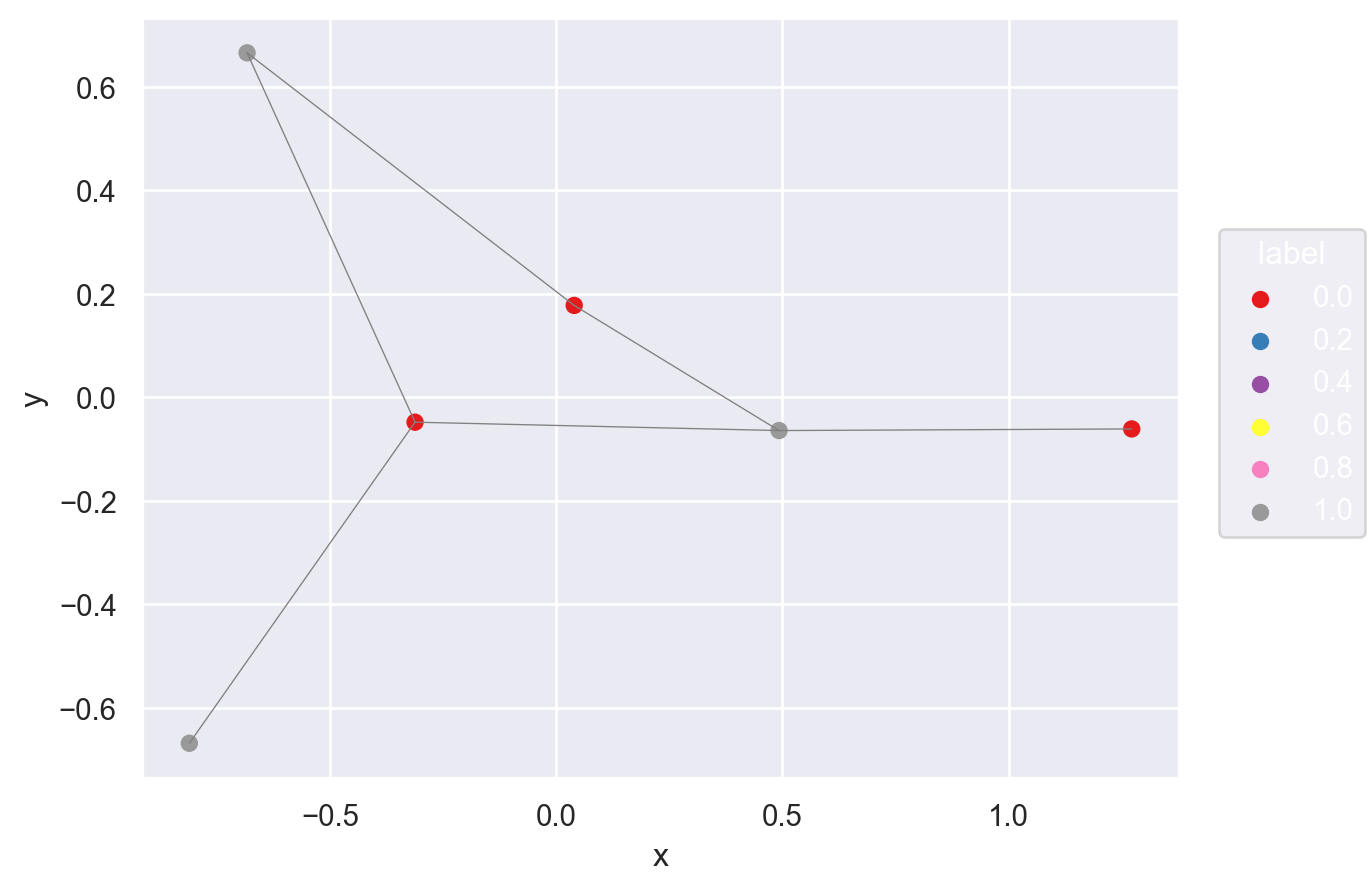

In [14]:
som.plot(palette="Set1", color="label", layout="pca")

In [15]:
som.topographic_error_

0.009

<Axes: >

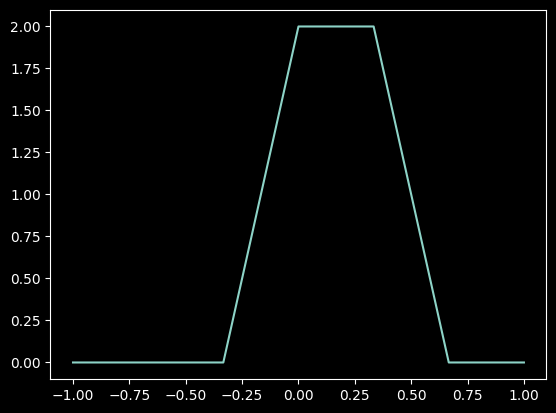

In [16]:
import seaborn as sns

te = som.topographic_function(X)
sns.lineplot(x=te[1], y=te[0])

In [17]:
import numpy as np

rmse_error = np.sqrt(np.mean(np.square(te[0])))

In [18]:
rmse_error

np.float64(1.0690449676496976)

In [19]:
import numpy as np
from sklearn.model_selection import GridSearchCV


def topographic_scorer(estimator, X, y=None):
    """GridSearchCV scorer based on the AUC of the topographic function.

    Returns the negative AUC so that GridSearchCV (which maximizes) picks
    the parameter set with the smallest topographic distortion.
    """
    te = estimator.topographic_function(X)
    phi_values, k_values = te[0], te[1]
    return -np.trapezoid(np.abs(phi_values), x=k_values)

In [21]:
param_grid = {
    "spreading_factor": [0.3, 0.5, 0.7, 0.9, 0.99],
    "sigma_end": [0.2, 0.5, 0.75, 1],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "convergence_iter": [1, 5, 10, 15],
}

grid_search = GridSearchCV(
    estimator=SomClassifier(n_iter=150, max_neurons=500),
    param_grid=param_grid,
    scoring=topographic_scorer,
    cv=5,
    verbose=2,
)
grid_search.fit(X, y)

print("Best params:", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.3; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.3; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.3; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.3; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.3; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.5; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.5; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.5; total time=   0.0s
[CV] END convergence_iter=1, learning_rate=0.02, sigma_end=0.2, spreading_factor=0.5; total time

KeyboardInterrupt: 